
# AI vs Human Voice Classification

In [ ]:

import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

BASE_DIR = '/content/ai_human_voice_classification_dataset/kaggle_before_after_dataset'  # change if needed
OUT_DIR = '/content/analysis_outputs'
os.makedirs(OUT_DIR, exist_ok=True)


In [ ]:
import os
import math
import zipfile
import warnings
from pathlib import Path

ZIP_PATH = "/content/AIHumanVoiceClassification.zip"   # change if your uploaded zip file has a different name
EXTRACT_DIR = Path("/content/ai_human_voice_classification_dataset")

if not os.path.exists(ZIP_PATH):
    print("Zip file not found. Please upload the dataset zip to Colab first.")
else:
    if not EXTRACT_DIR.exists():
        with zipfile.ZipFile(ZIP_PATH, "r") as z:
            z.extractall(EXTRACT_DIR)
    print("Dataset extracted to:", EXTRACT_DIR)

Dataset extracted to: /content/ai_human_voice_classification_dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1) Load metadata and map each sample to its audio file

In [ ]:

metadata = pd.read_csv(os.path.join(BASE_DIR, 'metadata.csv'))

def local_after(row):
    return glob.glob(os.path.join(BASE_DIR, 'AFTER_TRAIN', '*', row['label'], row['filename']))[0]

metadata['local_after'] = metadata.apply(local_after, axis=1)
metadata.head()


,filename,label,split,before_path,after_path,text,duration,local_after
0,human_083.wav,human,train,/content/before_after_dataset/BEFORE_TRAIN/hum...,/content/before_after_dataset/AFTER_TRAIN/trai...,"Hello, how are you doing today?",2.520,/content/ai_human_voice_classification_dataset...
1,human_019.wav,human,train,/content/before_after_dataset/BEFORE_TRAIN/hum...,/content/before_after_dataset/AFTER_TRAIN/trai...,Please remember to save your work regularly.,3.696,/content/ai_human_voice_classification_dataset...
2,human_052.wav,human,train,/content/before_after_dataset/BEFORE_TRAIN/hum...,/content/before_after_dataset/AFTER_TRAIN/trai...,Would you like some coffee or tea?,2.904,/content/ai_human_voice_classification_dataset...
3,ai_034.wav,ai,train,/content/before_after_dataset/BEFORE_TRAIN/ai/...,/content/before_after_dataset/AFTER_TRAIN/trai...,The project deadline is next Friday.,2.928,/content/ai_human_voice_classification_dataset...
4,ai_089.wav,ai,train,/content/before_after_dataset/BEFORE_TRAIN/ai/...,/content/before_after_dataset/AFTER_TRAIN/trai...,Could you please repeat that again?,2.328,/content/ai_human_voice_classification_dataset...


## 2) Feature extraction

In [ ]:

def extract_features(path):
    y, sr = librosa.load(path, sr=16000, mono=True)
    yt, _ = librosa.effects.trim(y, top_db=25)
    if len(yt) > sr // 2:
        y = yt

    duration = len(y) / sr
    rms = librosa.feature.rms(y=y)[0]
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)[0]
    flatness = librosa.feature.spectral_flatness(y=y)[0]

    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    try:
        f0 = librosa.yin(y, fmin=50, fmax=400, sr=sr)
        mask = rms[:len(f0)] > np.percentile(rms, 35)
        f0v = f0[mask]
        f0v = f0v[np.isfinite(f0v)]
        f0v = f0v[(f0v >= 50) & (f0v <= 400)]
        pitch_mean = float(np.mean(f0v)) if len(f0v) else 0.0
        pitch_std = float(np.std(f0v)) if len(f0v) else 0.0
        pitch_range = float(np.percentile(f0v, 95) - np.percentile(f0v, 5)) if len(f0v) else 0.0
    except Exception:
        pitch_mean = pitch_std = pitch_range = 0.0

    return {
        'duration': duration,
        'pitch_mean': pitch_mean,
        'pitch_std': pitch_std,
        'pitch_range': pitch_range,
        'spectral_centroid_mean': float(np.mean(centroid)),
        'spectral_bandwidth_mean': float(np.mean(bandwidth)),
        'spectral_rolloff_mean': float(np.mean(rolloff)),
        'spectral_flatness_mean': float(np.mean(flatness)),
        'zcr_mean': float(np.mean(zcr)),
        'rms_mean': float(np.mean(rms)),
    }


In [ ]:

rows = []
for row in metadata.itertuples(index=False):
    feats = extract_features(row.local_after)
    feats.update({'filename': row.filename, 'label': row.label, 'text': row.text})
    rows.append(feats)

feat_df = pd.DataFrame(rows)
feat_df['chars_per_sec'] = feat_df['text'].str.len() / feat_df['duration']
feat_df['words_per_sec'] = feat_df['text'].str.split().str.len() / feat_df['duration']
feat_df['label_num'] = (feat_df['label'] == 'ai').astype(int)
feat_df.head()


,duration,pitch_mean,pitch_std,pitch_range,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,spectral_flatness_mean,zcr_mean,rms_mean,filename,label,text,chars_per_sec,words_per_sec,label_num
0,2.080,231.223650,55.562785,137.885670,1617.892503,1516.556694,3116.003788,0.014822,0.090946,0.114755,human_083.wav,human,"Hello, how are you doing today?",14.903846,2.884615,0
1,3.040,215.346663,42.427016,112.095552,1262.991311,1239.761449,2440.429688,0.006292,0.109105,0.110535,human_019.wav,human,Please remember to save your work regularly.,14.473684,2.302632,0
2,2.368,202.358248,39.260450,101.329437,1592.534038,1400.411684,2969.583333,0.027337,0.143431,0.097619,human_052.wav,human,Would you like some coffee or tea?,14.358108,2.956081,0
3,2.432,207.209090,40.782044,126.357609,1539.595260,1374.518249,2821.428571,0.020036,0.129376,0.094148,ai_034.wav,ai,The project deadline is next Friday.,14.802632,2.467105,1
4,1.856,207.487761,36.064101,108.358461,1362.953725,1374.056903,2717.558263,0.011187,0.092128,0.098477,ai_089.wav,ai,Could you please repeat that again?,18.857759,3.232759,1


## 3) Exploratory analysis

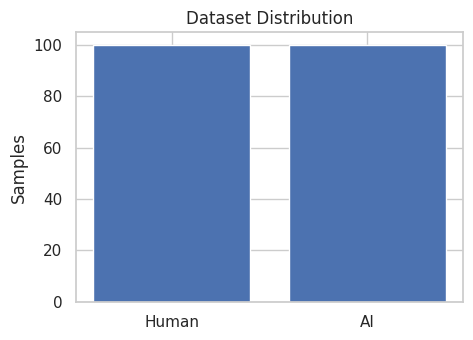

In [ ]:

sns.set_theme(style='whitegrid')
plt.figure(figsize=(5, 3.5))
counts = feat_df['label'].value_counts().reindex(['human', 'ai'])
plt.bar(['Human', 'AI'], counts.values)
plt.title('Dataset Distribution')
plt.ylabel('Samples')
plt.show()


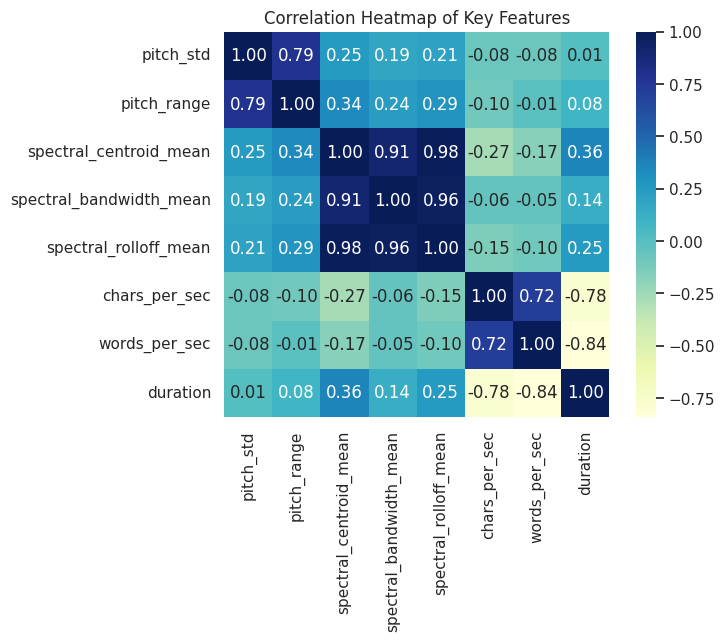

In [ ]:

key_cols = ['pitch_std', 'pitch_range', 'spectral_centroid_mean', 'spectral_bandwidth_mean', 'spectral_rolloff_mean', 'chars_per_sec', 'words_per_sec', 'duration']
plt.figure(figsize=(7, 5))
sns.heatmap(feat_df[key_cols].corr(), annot=True, fmt='.2f', cmap='YlGnBu', square=True)
plt.title('Correlation Heatmap of Key Features')
plt.show()


## 4) Train/test split and model comparison

In [ ]:

selected_features = ['duration', 'pitch_mean', 'pitch_std', 'pitch_range', 'spectral_centroid_mean', 'spectral_bandwidth_mean', 'spectral_rolloff_mean', 'spectral_flatness_mean', 'chars_per_sec', 'words_per_sec', 'zcr_mean', 'rms_mean']
X = feat_df[selected_features]
y = feat_df['label_num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Logistic Regression': Pipeline([('imputer', SimpleImputer()), ('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=4000, random_state=42))]),
    'Support Vector Machine': Pipeline([('imputer', SimpleImputer()), ('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', probability=True, random_state=42))]),
    'Random Forest': Pipeline([('imputer', SimpleImputer()), ('clf', RandomForestClassifier(n_estimators=300, random_state=42))]),
}

metrics = []
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    metrics.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1 Score': f1_score(y_test, preds),
    })
    predictions[name] = {'preds': preds, 'probs': probs, 'cm': confusion_matrix(y_test, preds)}

metrics_df = pd.DataFrame(metrics).sort_values('Accuracy', ascending=False)
metrics_df


,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.975,0.952381,1.0,0.975610
1,Support Vector Machine,0.950,0.909091,1.0,0.952381
0,Logistic Regression,0.925,0.869565,1.0,0.930233


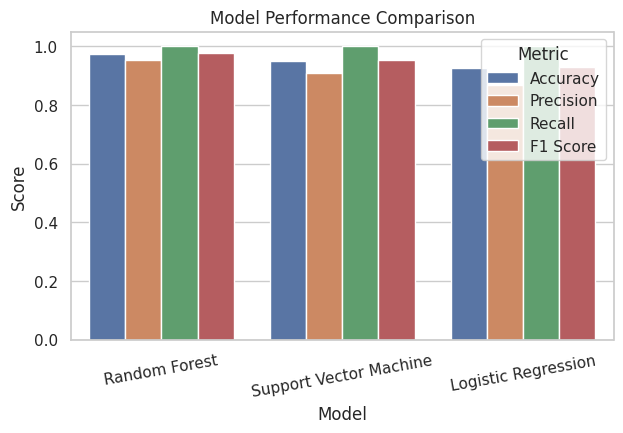

In [ ]:

plot_df = metrics_df.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'], var_name='Metric', value_name='Score')
plt.figure(figsize=(7, 4))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric')
plt.ylim(0, 1.05)
plt.title('Model Performance Comparison')
plt.xticks(rotation=10)
plt.show()


## 5) Feature importance and confusion matrix

In [ ]:

rf = models['Random Forest'].named_steps['clf']
importance_df = pd.DataFrame({'Feature': selected_features, 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False)
importance_df.head(10)


,Feature,Importance
8,chars_per_sec,0.207321
5,spectral_bandwidth_mean,0.163971
6,spectral_rolloff_mean,0.112190
4,spectral_centroid_mean,0.100667
1,pitch_mean,0.100133
0,duration,0.063063
9,words_per_sec,0.054074
2,pitch_std,0.044605
11,rms_mean,0.042822
10,zcr_mean,0.040100


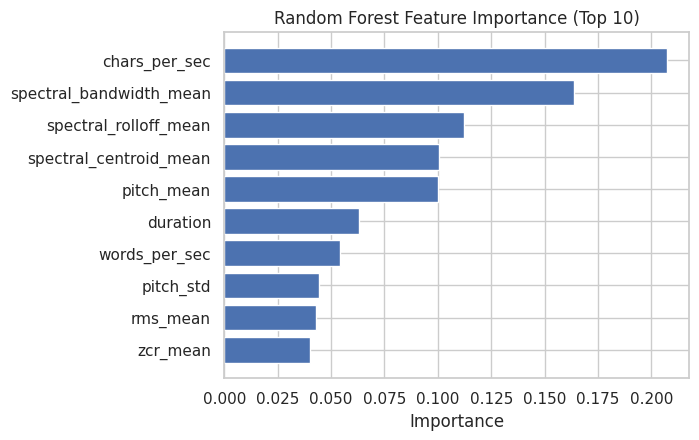

In [ ]:

plt.figure(figsize=(6, 4.5))
plot_imp = importance_df.head(10).sort_values('Importance')
plt.barh(plot_imp['Feature'], plot_imp['Importance'])
plt.title('Random Forest Feature Importance (Top 10)')
plt.xlabel('Importance')
plt.show()


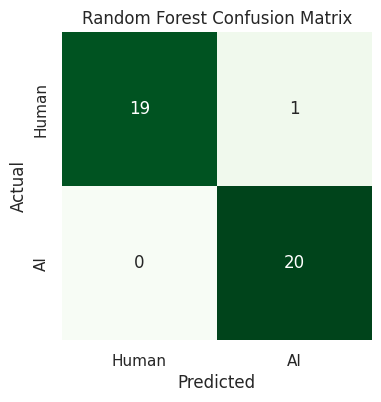

In [ ]:

cm = predictions['Random Forest']['cm']
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False, xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 6) Hypothesis tests

In [ ]:

ai = feat_df[feat_df['label'] == 'ai']
human = feat_df[feat_df['label'] == 'human']
rows = []
for feature, family, hypothesis in [
    ('pitch_std', 'Pitch variability', 'H1'),
    ('pitch_range', 'Pitch variability', 'H1'),
    ('spectral_centroid_mean', 'Spectral features', 'H2'),
    ('spectral_bandwidth_mean', 'Spectral features', 'H2'),
    ('spectral_rolloff_mean', 'Spectral features', 'H2'),
    ('chars_per_sec', 'Speech rhythm proxy', 'H3'),
    ('words_per_sec', 'Speech rhythm proxy', 'H3'),
    ('duration', 'Speech rhythm proxy', 'H3'),
]:
    test = ttest_ind(ai[feature], human[feature], equal_var=False, nan_policy='omit')
    rows.append({
        'Hypothesis': hypothesis,
        'Feature': feature,
        'AI Mean': ai[feature].mean(),
        'Human Mean': human[feature].mean(),
        'p-value': test.pvalue,
        'Supported': 'Yes' if test.pvalue < 0.05 else 'No'
    })

hypothesis_df = pd.DataFrame(rows)
hypothesis_df


,Hypothesis,Feature,AI Mean,Human Mean,p-value,Supported
0,H1,pitch_std,43.027997,45.872050,7.528324e-03,Yes
1,H1,pitch_range,126.705427,139.601308,4.106513e-04,Yes
2,H2,spectral_centroid_mean,1490.767503,1799.927826,2.543502e-16,Yes
3,H2,spectral_bandwidth_mean,1361.524845,1493.309956,2.451958e-13,Yes
4,H2,spectral_rolloff_mean,2726.854828,3205.405527,1.151845e-14,Yes
5,H3,chars_per_sec,15.974174,14.251611,2.915191e-14,Yes
6,H3,words_per_sec,2.589126,2.313684,2.645205e-03,Yes
7,H3,duration,2.643200,2.978560,1.168713e-04,Yes



## 7) Interpretation summary

- Random Forest is the best of the three required models on the 80/20 split.
- Spectral features are highly discriminative.
- Pitch variability also differs significantly between AI and human speech.
- Speech rhythm is supported in this dataset through articulation-rate proxies and duration.
- The very strong results should be interpreted cautiously because the dataset is small and controlled.
